In [14]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from mypyc.ir.ops import RaiseStandardError

# Using _trajectory-container-tools_ with ROS Bags


## Specify the rosbag path

**Requirements**

The ROS bag must contain valid ROS message topics with proper timestamps. Supported message types include `nav_msgs/Odometry`, `sensor_msgs/Imu`, `tf2_msgs/TFMessage`, `ackermann_msgs/AckermannDriveStamped` and more, plus you can implement your own, its realy easy.


In [15]:
# .... Path to ROS bag in 'external_data' directory ............................................

# BAG = "2024-03-21_12-19-00" # small circle
# BAG = "2024-03-21_12-23-53" # medium spiral
# BAG = "2024-03-21_12-25-29" # empty
BAG = "2024-03-21_14-52-35" # ★★ 8408 timestpes
# BAG = "2024-03-21_15-01-04" # empty
# BAG = "2024-03-21_15-03-19" # empty
# BAG = "2024-03-21_15-14-09" # ★★ 63063 timesteps
# BAG = "2024-03-21_15-26-13" # ★ 35128 timesteps
# BAG = "2024-03-21_15-35-28" # ★ 179236 timesteps
rosbag_path = os.path.join( "external_data", "rosbag-vaul-f110-grand-salon-raw-msg", BAG)

# .... Path to ROS bag in 'demo_data' directory ................................................

# BAG = "2024-03-21_12-25-29" # empty
# # BAG = "2024-03-21_15-01-04" # empty
# rosbag_path = os.path.join( "demo_data", "rosbag_test_data", "rosbag-vaul-f110-grand-salon-raw-msg", BAG)

print(f"Using ROS bag: {rosbag_path}")

Using ROS bag: external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_15-35-28


## Introspect the ros bag contents

In [16]:
from trajectory_container_tools.rosbag_to_tct import show_available_rosbag_topics
from trajectory_container_tools.utils.ros2_non_native_msg import register_ros2_non_native_msg

# Register non-native ros message
register_ros2_non_native_msg()

rosbag_path = show_available_rosbag_topics(rosbag_path)

Using ROS bag: /ros2_ws/src/trajectory-container-tools/external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_15-35-28
Available topics:
  /robot_description: std_msgs/msg/String
  /scan: sensor_msgs/msg/LaserScan
  /odom: nav_msgs/msg/Odometry
  /sensors/imu/raw: sensor_msgs/msg/Imu
  /teleop: ackermann_msgs/msg/AckermannDriveStamped
Total messages: 495454


## 1. Basic ROS Bag Processing

Extract multiple features from a ROS bag based on a configuration dictionary.

```python
def aggregate_multiple_features_from_rosbag(
        rosbag_path: Path,
        dataset_info: str,
        features_config: dict[str, Union[Type[RosBagFeatureDataclass], tuple[str, ...]]]
    ) -> dataclass:
    ...
```
- param `rosbag_path`: Path to the ROS bag directory or file
- param `dataset_info`: Any relevant information pertaining to the dataset (robot, environment, test conditions ...)
- param `features_config`: The ROS message features to aggregate from the bag as a configuration dictionary

### Define which topic to extract

The `features_config` specifies the ROS message types to extract from the bag and aggregate them in a `Multifeature` dataclass. Message types are specified using existing `RosBagFeatureDataclass` subclasses such as: `NavMsgsOdometry`, `SensorMsgsImu`, `Tf2MsgsTFMessage`, `AckermannMsgsAckermannDriveStamped` or by using tuple of strings for custom message structures.

The `features_config` parameter specify the feature name and type (i.e. topic name and type)
to lookout in the rosbag topic list and agregate them in a *multifeature* dataclass.

Feature dimensions such as `pose.position.x` or `twist.linear.y` are specified either by using existing `RosBagFeatureDataclass` subclass such as: `NavMsgsOdometry`, `AckermannMsgsAckermannDriveStamped`, `Tf2MsgsTFMessage`, `SensorMsgsImu` or by using tuple of strings such as `('<NewFeatureDataclassTypeName>', '<topic_property_name_1>', '<topic_property_name_2>', ...)` with `NewFeatureDataclassTypeName` being the ros topic type, in camelback notation, without the `/msg` directory e.g., `Tf2MsgsTFMessage` -> `tf2_msgs/msg/TFMessage`.

```python
feature_config = {
    '/pf/pose/odom': NavMsgsOdometry,
    '/odom':         NavMsgsOdometry,
    '/tf':           ('Tf2MsgsTFMessage', 'transform_translation_x',
                                          'transform_translation_y',
                                          'transform_translation_z')
}
```
Topic property name `drive_steeringAngleVelocity` would convert to ros topic msg `drive.steering_angle_velocity`. The parsing rule for topic property name is:
 - underscore `_` convert to dot `.`
 - `CamelCase` convert to `snake_case`.

💎 Note that each `RosBagFeatureDataclass` subclass validates that extracted data has proper timestamps and uniform shape.


In [17]:
from trajectory_container_tools.rosbag_to_tct import aggregate_multiple_features_from_rosbag
from trajectory_container_tools.trj_dataclasses.rosbag_feature_dataclass import NavMsgsOdometry

# Basic configuration - extract odometry
features_config_1 = {
    "/odom": NavMsgsOdometry,
}

mf1 = aggregate_multiple_features_from_rosbag(
    rosbag_path,
    dataset_info=f"Robot: f110_race_car, Track: grand_salon, Run: {BAG}",
    features_config=features_config_1
)
print("Successfully extracted features!")

[TCT] Extract single feature from rosbag › seeking /odom


[TCT] Collect topic /odom msg from rosbag: 100%|██████████| 179236/179236 [00:08<00:00, 20969.15it/s]
[TCT] Post-process rosbag data to NavMsgsOdometry fields: 100%|██████████| 5/5 [00:00<00:00, 10.31it/s]

Successfully extracted features!



## 2. Accessing ROS Message Data

ROS message data can be accessed through the structured dataclass attributes. Each message type provides access to its specific fields.


In [18]:
print(mf1)


Multifeature(
   dataset_info: Robot: f110_race_car, Track: grand_salon, Run: 2024-03-21_15-35-28
   aggregated_date: 2025-09-08 14:03:21.808236
   topic_odom: 
          NavMsgsOdometry(
             feature_name: /odom
             trajectory_len: 179236
             transposed: False
             dimensions:
                header_FrameId: (str) odom
                timestamps: (ndarray) shape (179236,) range(nanosec) 1711049729403701368 ⟶ 1711051604393350556
                pose:          
                    PoseWithCovariance(
                       trajectory_len: 179236
                       transposed: False
                       dimensions:
                          pose:          
                              Pose(
                                 trajectory_len: 179236
                                 transposed: False
                                 dimensions:
                                    position_x: (ndarray) shape (179236,) range -95.88993236507076 ⟶ 22.0659

In [19]:
# Access position data
position_x: np.ndarray = mf1.topic_odom.pose.pose.position_x
position_y: np.ndarray = mf1.topic_odom.pose.pose.position_y
timestamps: np.ndarray = mf1.topic_odom.timestamps

print(f"Extracted {len(position_x)} data points")
print(f"Position X range: {np.min(position_x)} to {np.max(position_x)} m")
print(f"Position Y range: {np.min(position_y)} to {np.max(position_y)} m")
print(f"Time duration: {(timestamps[-1] - timestamps[0])}")


Extracted 179236 data points
Position X range: -95.88993236507076 to 22.065919702907426 m
Position Y range: -78.17808915534775 to 4.1535235922153335 m
Time duration: 1874989649188 nanoseconds


## 3. Trajectory Visualization

Visualize the extracted trajectory data to understand robot motion patterns.


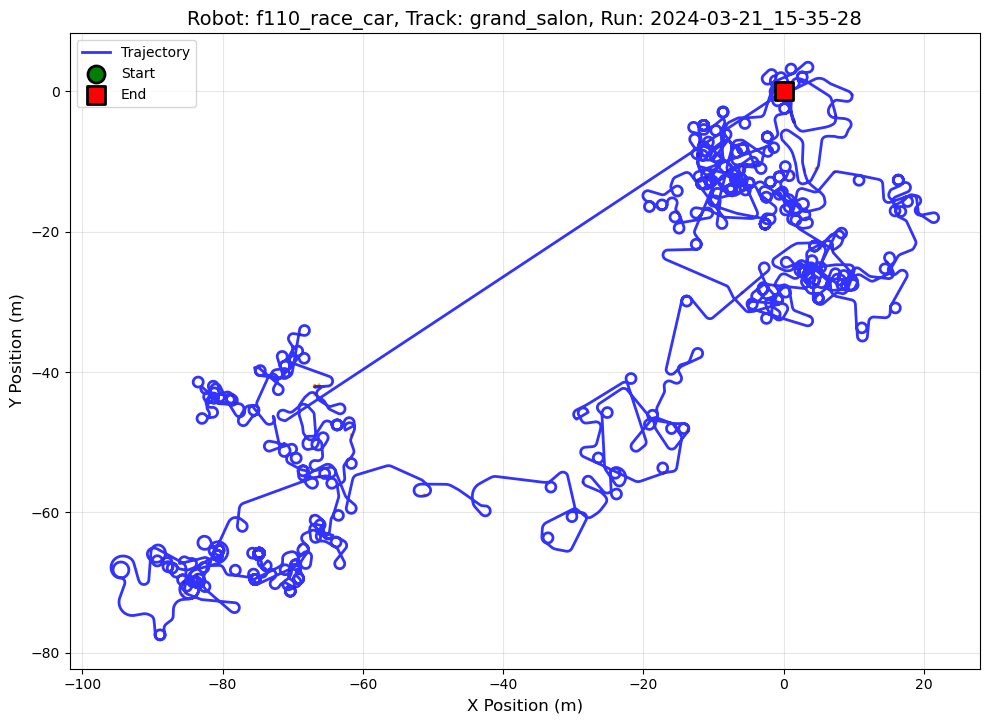

(<Figure size 1000x800 with 1 Axes>,
 <AxesSubplot:title={'center':'Robot: f110_race_car, Track: grand_salon, Run: 2024-03-21_15-35-28'}, xlabel='X Position (m)', ylabel='Y Position (m)'>)

In [20]:
from trajectory_container_tools.utils.plot import plot_trajectory_2d

plot_trajectory_2d(mf1)

## 4. Velocity and Control Analysis

Analyze the robot's velocity profile and control characteristics.


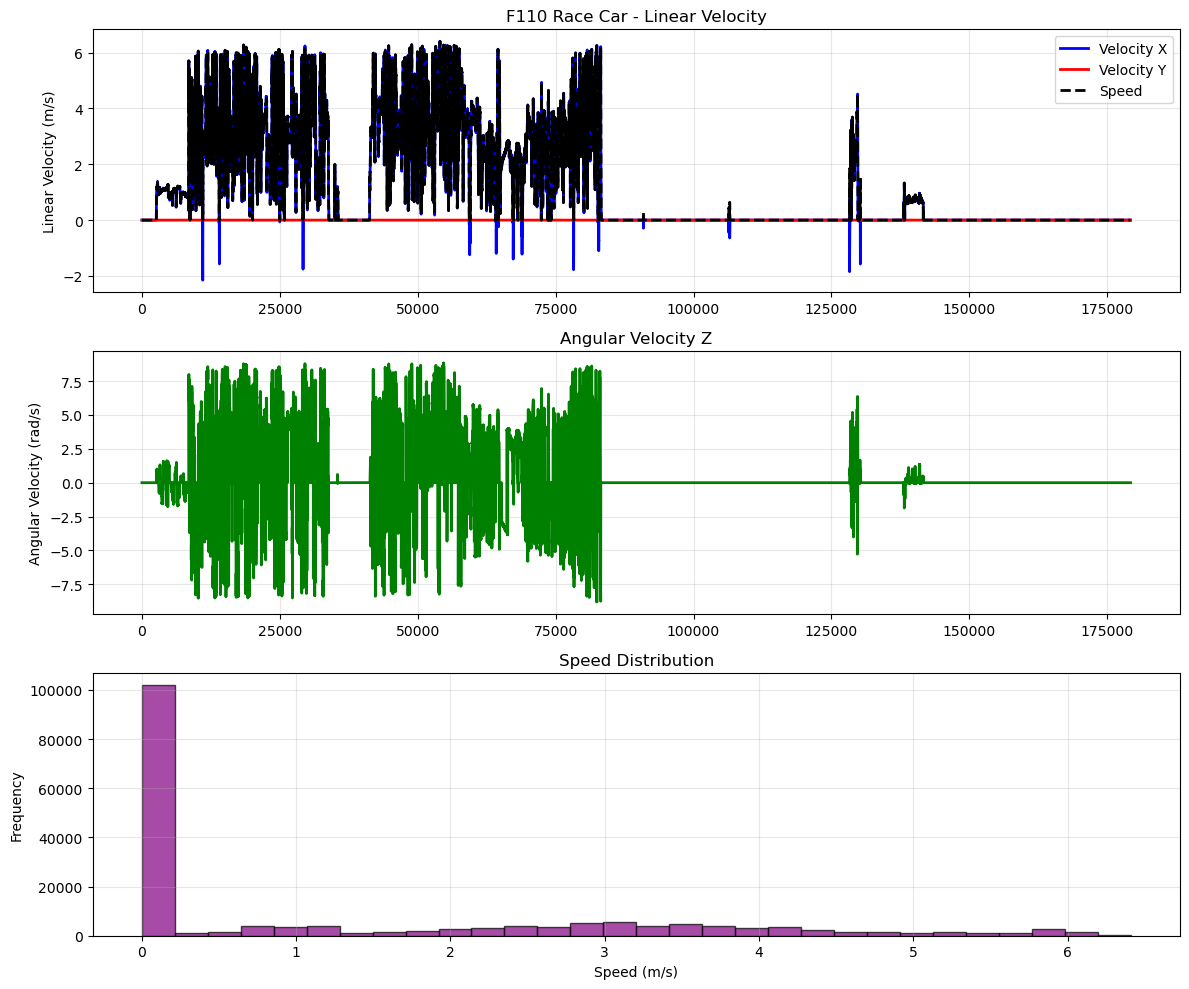


Velocity Statistics:
Max speed: 6.409 m/s
Mean speed: 1.324 m/s
Max angular velocity: 8.828 rad/s (505.8 deg/s)


In [21]:
from typing import Union
from trajectory_container_tools import BaseTrajectoryDataclass

def plot_velocity_analysis(trajectory_data: Union[BaseTrajectoryDataclass], title: str = "Velocity Analysis"):
    """Plot velocity components and speed over time."""
    _vel_x = trajectory_data.fetch_nested_attribute("topic_odom.twist.twist.linear_x")
    _vel_y = trajectory_data.fetch_nested_attribute("topic_odom.twist.twist.linear_y")
    _angular_z = trajectory_data.fetch_nested_attribute("topic_odom.twist.twist.angular_z")
    _timestep_index = trajectory_data.fetch_nested_attribute("topic_odom.timestep_index")

    # Calculate speed
    _speed = np.sqrt(_vel_x**2 + _vel_y**2)

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    # Linear velocity components
    axes[0].plot(_timestep_index, _vel_x, 'b-', label='Velocity X', linewidth=2)
    axes[0].plot(_timestep_index, _vel_y, 'r-', label='Velocity Y', linewidth=2)
    axes[0].plot(_timestep_index, _speed, 'k--', label='Speed', linewidth=2)
    axes[0].set_ylabel('Linear Velocity (m/s)')
    axes[0].set_title(f'{title} - Linear Velocity')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Angular velocity
    axes[1].plot(_timestep_index, _angular_z, 'g-', linewidth=2)
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_title('Angular Velocity Z')
    axes[1].grid(True, alpha=0.3)

    # Speed histogram
    axes[2].hist(_speed, bins=30, alpha=0.7, color='purple', edgecolor='black')
    axes[2].set_xlabel('Speed (m/s)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Speed Distribution')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, axes

# Analyze velocity profile
plot_velocity_analysis(mf1, "F110 Race Car")
plt.show()

# Print velocity statistics
vel_x = mf1.topic_odom.twist.twist.linear_x
vel_y = mf1.topic_odom.twist.twist.linear_y
speed = np.sqrt(vel_x**2 + vel_y**2)
angular_z = mf1.topic_odom.twist.twist.angular_z

print(f"\nVelocity Statistics:")
print(f"Max speed: {np.max(speed):.3f} m/s")
print(f"Mean speed: {np.mean(speed):.3f} m/s")
print(f"Max angular velocity: {np.max(np.abs(angular_z)):.3f} rad/s ({np.degrees(np.max(np.abs(angular_z))):.1f} deg/s)")

## 5. Advanced Processing with Custom Post-Processing

Create custom feature classes with specialized post-processing for racing data analysis.


In [22]:
from trajectory_container_tools import extract_single_feature_from_rosbag
from rclpy.time import Time as RosTime
from rclpy.duration import Duration as RosDuration

@dataclass
class RacingOdometryAnalysis(NavMsgsOdometry):
    """Custom odometry analysis for racing applications."""

    def post_init_feature_callback(self, feature_name):
        """Calculate racing-specific metrics."""

        if feature_name == "pose":
            # Calculate trajectory metrics when position data is processed
            x = self.fetch_nested_attribute("pose.pose.position_x")
            y = self.fetch_nested_attribute("pose.pose.position_y")

            # Calculate path length
            dx = np.diff(x)
            dy = np.diff(y)
            segment_lengths = np.sqrt(dx**2 + dy**2)
            path_length = np.sum(segment_lengths)
            self.set_dynamic_field('path_length', path_length)

        elif feature_name == "twist":
            # Calculate acceleration when velocity data is processed
            _vel_x = self.fetch_nested_attribute("twist.twist.linear_x")
            _vel_y = self.fetch_nested_attribute("twist.twist.linear_y")

            # Calculate speed and acceleration
            _speed = np.sqrt(_vel_x**2 + _vel_y**2)
            self.set_dynamic_field('speed', _speed)

            if len(self.timestamps) > 1:
                dt = np.diff(self.timestamps)
                if isinstance(dt[0], (RosTime, RosDuration)):
                    dt = np.array([dt[each].nanoseconds for each in np.arange(len(dt))])
                acceleration = np.diff(_speed) / dt
                # Pad to match length
                self.set_dynamic_field('acceleration', np.concatenate([[0], acceleration]))
            else:
                self.set_dynamic_field('acceleration', np.zeros_like(_speed))

        return None

racing_data = extract_single_feature_from_rosbag(rosbag_path,feature_name='/odom',data_container_type=RacingOdometryAnalysis)
print("Racing analyses complete!")

[TCT] Extract single feature from rosbag › seeking /odom


[TCT] Collect topic /odom msg from rosbag: 100%|██████████| 179236/179236 [00:08<00:00, 20673.73it/s]
[TCT] Post-process rosbag data to RacingOdometryAnalysis fields: 100%|██████████| 5/5 [00:00<00:00, 11.37it/s]


Racing analyses complete!


In [23]:
print("RacingOdometryAnalysis dimension names:", RacingOdometryAnalysis.get_dimension_names())
print(racing_data)

RacingOdometryAnalysis dimension names: ('header_FrameId', 'timestamps', 'pose', 'twist')

          RacingOdometryAnalysis(
             feature_name: /odom
             trajectory_len: 179236
             transposed: False
             dimensions:
                header_FrameId: (str) odom
                timestamps: (ndarray) shape (179236,) range(nanosec) 1711049729403701368 ⟶ 1711051604393350556
                pose:          
                    PoseWithCovariance(
                       trajectory_len: 179236
                       transposed: False
                       dimensions:
                          pose:          
                              Pose(
                                 trajectory_len: 179236
                                 transposed: False
                                 dimensions:
                                    position_x: (ndarray) shape (179236,) range -95.88993236507076 ⟶ 22.065919702907426
                                    position_y: (nda

In [24]:
print(f"\nRacing Analysis Results:")
print(f"  Total path length: {racing_data.path_length} meters")
print(f"  Maximum speed: {np.max(racing_data.speed):.2f} m/s")
print(f"  Maximum acceleration: {np.max(np.abs(racing_data.acceleration)):.2f} m/s²")


Racing Analysis Results:
  Total path length: 2486.259664468796 meters
  Maximum speed: 6.41 m/s
  Maximum acceleration: 0.00 m/s²


## 6. Multi-Feature ROS Bag Analysis

Process multiple ROS message types simultaneously for comprehensive robot behavior analysis.


In [25]:
# Advanced multi-feature configuration
from trajectory_container_tools.trj_dataclasses.rosbag_feature_dataclass import SensorMsgsImu

multi_features_config = {
    "/odom": RacingOdometryAnalysis,
    "/sensors/imu/raw": SensorMsgsImu,
}

multi_data = aggregate_multiple_features_from_rosbag(
    rosbag_path,
    dataset_info="Multi-sensor F110 data analysis",
    features_config=multi_features_config
)
print("Multi-feature extraction successful!")

multi_data.summary


[TCT] Extract single feature from rosbag › seeking /odom


[TCT] Collect topic /odom msg from rosbag: 100%|██████████| 179236/179236 [00:08<00:00, 20913.58it/s]
[TCT] Post-process rosbag data to RacingOdometryAnalysis fields: 100%|██████████| 5/5 [00:00<00:00, 12.15it/s]


[TCT] Extract single feature from rosbag › seeking /sensors/imu/raw


[TCT] Collect topic /sensors/imu/raw msg from rosbag: 100%|██████████| 179759/179759 [00:06<00:00, 26508.46it/s]
[TCT] Post-process rosbag data to SensorMsgsImu fields: 100%|██████████| 16/16 [00:00<00:00, 41.15it/s]


Multi-feature extraction successful!

Multifeature(
   dataset_info: Multi-sensor F110 data analysis
   aggregated_date: 2025-09-08 14:03:53.470198
   topic_odom: 
          RacingOdometryAnalysis(
             feature_name: /odom
             trajectory_len: 179236
             transposed: False
             dimensions:
                header_FrameId: (str) odom
                timestamps: (ndarray) shape (179236,) range(nanosec) 1711049729403701368 ⟶ 1711051604393350556
                pose:          
                    PoseWithCovariance(
                       trajectory_len: 179236
                       transposed: False
                       dimensions:
                          pose:          
                              Pose(
                                 trajectory_len: 179236
                                 transposed: False
                                 dimensions:
                                    position_x: (ndarray) shape (179236,) range -95.88993236507076 

## 7. Racing Performance Visualization

Visualize racing-specific metrics including speed profiles, acceleration, and track curvature.


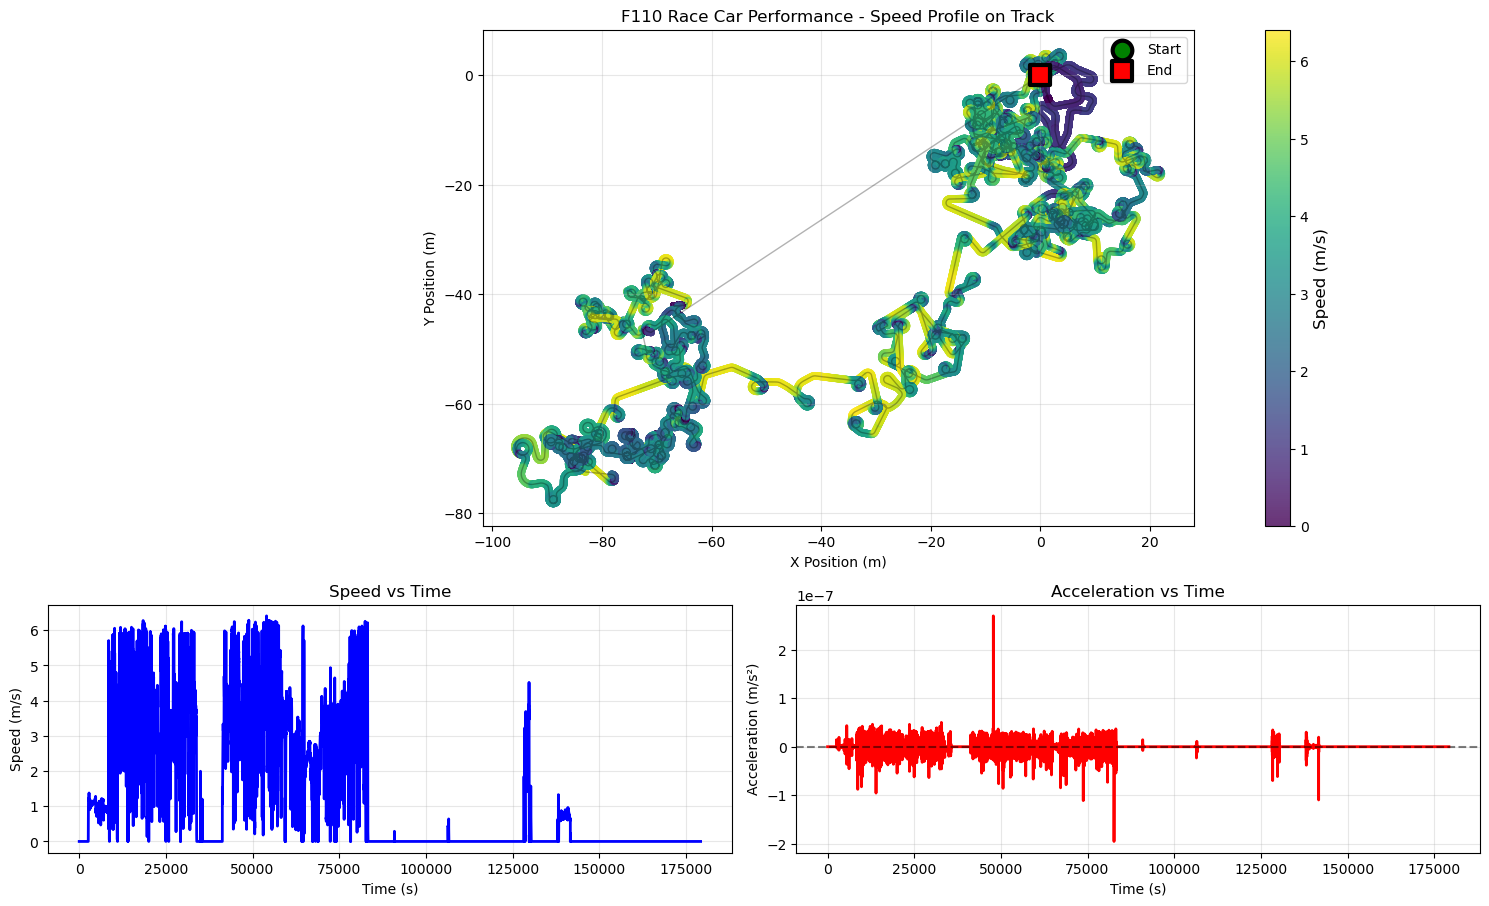

In [26]:
def plot_racing_analysis(racing_data, title: str = "Racing Performance Analysis"):
    """Plot comprehensive racing analysis."""
    odom = racing_data.topic_odom

    fig = plt.figure(figsize=(15, 12))

    # Create a 2x3 grid of subplots
    gs = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1])

    # 1. Trajectory with speed colormap
    ax1 = fig.add_subplot(gs[0, :])
    x = odom.pose.pose.position_x
    y = odom.pose.pose.position_y
    _speed = odom.speed

    scatter = ax1.scatter(x, y, c=_speed, cmap='viridis', s=20, alpha=0.8)
    ax1.plot(x, y, 'k-', alpha=0.3, linewidth=1)
    ax1.scatter(x[0], y[0], color='green', s=200, marker='o',
               label='Start', edgecolor='black', linewidth=3, zorder=5)
    ax1.scatter(x[-1], y[-1], color='red', s=200, marker='s',
               label='End', edgecolor='black', linewidth=3, zorder=5)

    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Speed (m/s)', fontsize=12)
    ax1.set_xlabel('X Position (m)')
    ax1.set_ylabel('Y Position (m)')
    ax1.set_title(f'{title} - Speed Profile on Track')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')

    # 2. Speed vs time
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(odom.timestep_index, _speed, 'b-', linewidth=2)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Speed (m/s)')
    ax2.set_title('Speed vs Time')
    ax2.grid(True, alpha=0.3)

    # 3. Acceleration vs time
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(odom.timestep_index, odom.acceleration, 'r-', linewidth=2)
    ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Acceleration (m/s²)')
    ax3.set_title('Acceleration vs Time')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# Create racing analysis visualization
plot_racing_analysis(multi_data, "F110 Race Car Performance")
plt.show()

## Summary

This notebook demonstrated comprehensive ROS bag processing with Trajectory Container Tools:

1. **Basic Feature Extraction**: Loading and processing ROS bag data
2. **Data Access**: Accessing structured ROS message data
3. **Visualization**: Creating trajectory and velocity plots
4. **Custom Processing**: Implementing racing-specific analysis
5. **Multi-Feature Analysis**: Processing multiple ROS message types

### Key Features Demonstrated:

- **ROS Message Support**: `nav_msgs/Odometry`, `tf2_msgs/TFMessage`, `sensor_msgs/Imu`
- **Automatic Validation**: Timestamp synchronization and data consistency
- **Custom Post-Processing**: Domain-specific analysis (racing metrics)
- **Comprehensive Visualization**: Trajectory, speed, acceleration, and curvature analysis
